# ❤️ Clasificación de Enfermedades Cardíacas
## K-Nearest Neighbors (KNN) vs Support Vector Machine (SVM)

**Consigna:** Elegir 2 modelos de clasificación y aplicarlos sobre un dataset de interés para resolver un problema de aprendizaje automático. Evaluar cada modelo y concluir cuál aborda mejor el problema.

---

### 🎯 Problema planteado
Predecir si un paciente tiene **enfermedad cardíaca** (`HeartDisease`: 0 = No, 1 = Sí) a partir de variables clínicas y de laboratorio.

Es un problema de **clasificación binaria supervisada** con alto impacto médico: un **falso negativo** (no detectar una enfermedad real) tiene consecuencias graves.

### 📦 Modelos seleccionados
1. **KNN — K-Nearest Neighbors**: clasifica por similitud/distancia con los vecinos más cercanos
2. **SVM — Support Vector Machine**: encuentra el hiperplano que maximiza el margen entre clases

### 📁 Dataset
- **Fuente:** Heart Disease Dataset (918 pacientes)
- **Features:** 11 variables clínicas (edad, sexo, tipo de dolor, presión, colesterol, ECG, etc.)
- **Target:** `HeartDisease` (0 = No, 1 = Sí)

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_curve, auc
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3d4a', 'text.color': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0', 'xtick.color': '#a0a0a0',
    'ytick.color': '#a0a0a0', 'grid.color': '#2a2d3a',
    'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3,
})
COLORS = {
    'positive': '#ff6b6b',
    'negative': '#4ecdc4',
    'knn':      '#ffd166',
    'svm':      '#a29bfe',
    'neutral':  '#74b9ff'
}
print('Librerias importadas correctamente')

Librerias importadas correctamente


## 2. Carga y Exploración del Dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `Age` | Numérica | Edad del paciente |
| `Sex` | Categórica | M = Masculino, F = Femenino |
| `ChestPainType` | Categórica | ATA, NAP, ASY, TA |
| `RestingBP` | Numérica | Presión arterial en reposo (mmHg) |
| `Cholesterol` | Numérica | Colesterol sérico (mg/dL) |
| `FastingBS` | Binaria | Glucemia en ayunas > 120 mg/dL (1=Sí) |
| `RestingECG` | Categórica | ECG en reposo (Normal, ST, LVH) |
| `MaxHR` | Numérica | Frecuencia cardíaca máxima |
| `ExerciseAngina` | Binaria | Angina inducida por ejercicio (Y/N) |
| `Oldpeak` | Numérica | Depresión del ST inducida por ejercicio |
| `ST_Slope` | Categórica | Pendiente del segmento ST (Up, Flat, Down) |
| `HeartDisease` | **TARGET** | 0 = No, 1 = Sí |

In [ ]:
df = pd.read_csv('DataSet_Heart_Disease.csv')

print(f'Shape del dataset: {df.shape}')
print(f'  -> {df.shape[0]} pacientes | {df.shape[1]} variables')
print(f'\nVariable objetivo (HeartDisease):')
print(df['HeartDisease'].value_counts())
print(f'\nTasa de enfermedad: {df["HeartDisease"].mean()*100:.1f}%')
df.head(8)

Shape del dataset: (918, 12)
  -> 918 pacientes | 12 variables

Variable objetivo (HeartDisease):
HeartDisease
1    508
0    410
Name: count, dtype: int64

Tasa de enfermedad: 55.3%


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0


In [3]:
print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print('\n=== VALORES NULOS ===')
print(df.isnull().sum())
print('\n=== ESTADISTICAS DESCRIPTIVAS ===')
df.describe().round(2)

=== TIPOS DE DATOS ===
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

=== VALORES NULOS ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

=== ESTADISTICAS DESCRIPTIVAS ===


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


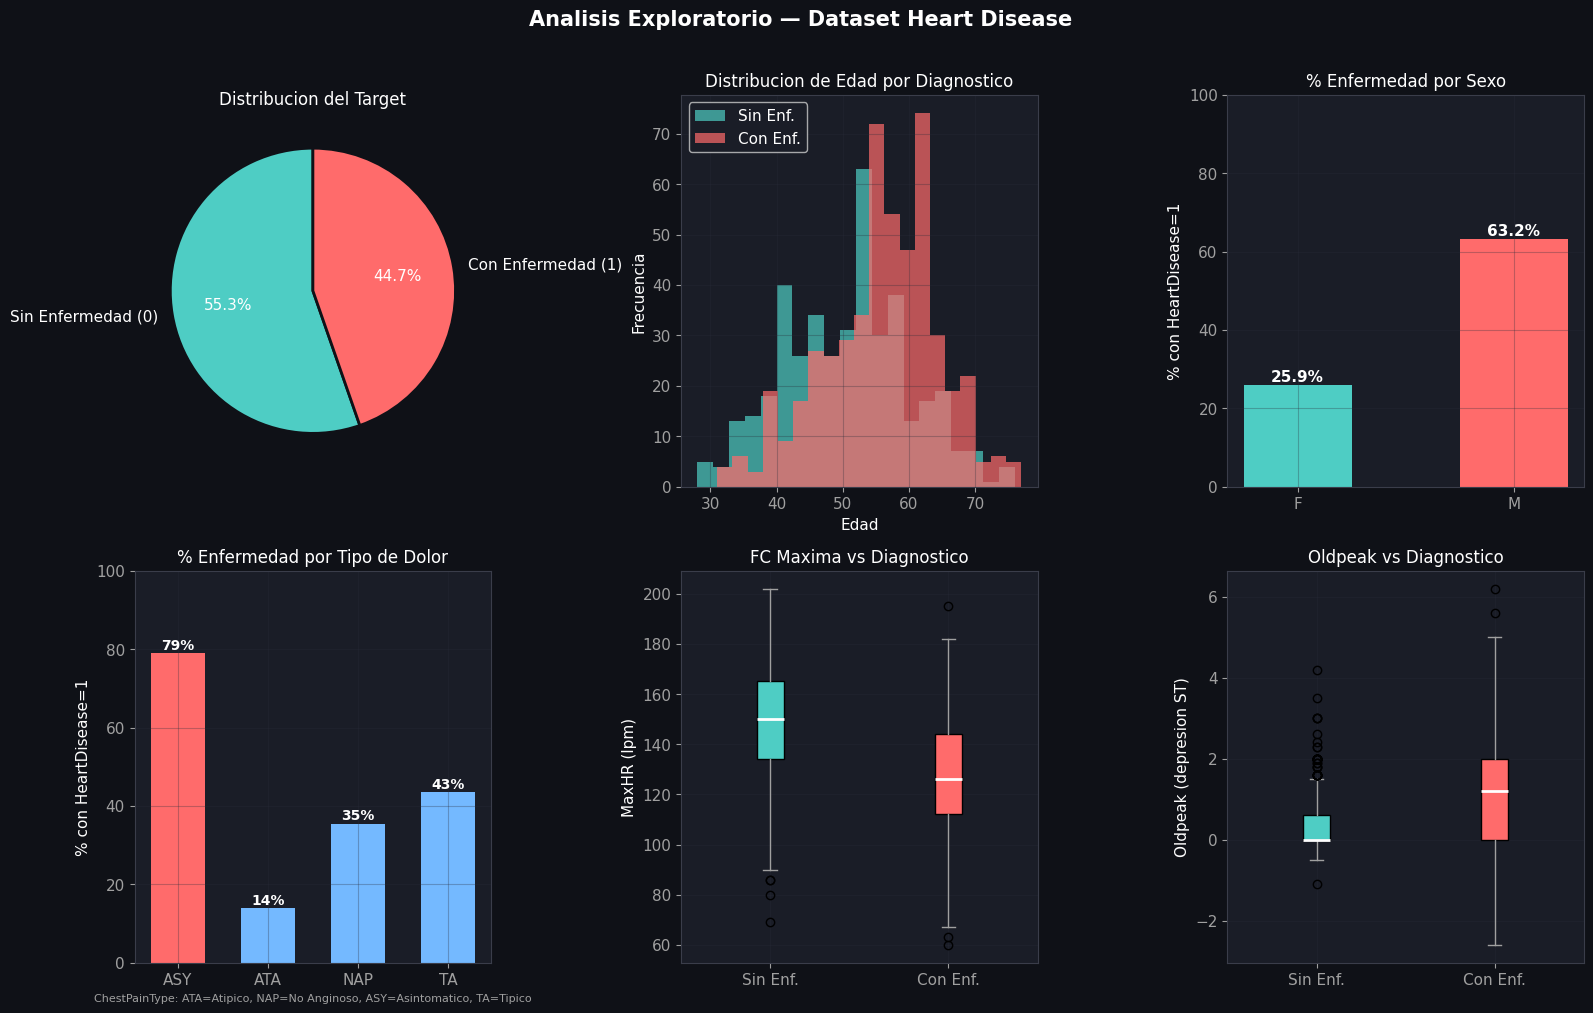

In [4]:
# EDA visual — 6 gráficos
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#0f1117')

# 1. Distribución del target
counts = df['HeartDisease'].value_counts()
axes[0,0].pie(counts, labels=['Sin Enfermedad (0)','Con Enfermedad (1)'],
              colors=[COLORS['negative'], COLORS['positive']],
              autopct='%1.1f%%', startangle=90,
              textprops={'color':'white','fontsize':11},
              wedgeprops={'edgecolor':'#0f1117','linewidth':2})
axes[0,0].set_title('Distribucion del Target', color='white', fontsize=12)

# 2. Edad por enfermedad
for val, color, label in [(0, COLORS['negative'], 'Sin Enf.'), (1, COLORS['positive'], 'Con Enf.')]:
    axes[0,1].hist(df[df['HeartDisease']==val]['Age'], bins=20,
                   color=color, alpha=0.7, label=label, edgecolor='none')
axes[0,1].set_title('Distribucion de Edad por Diagnostico', color='white', fontsize=12)
axes[0,1].set_xlabel('Edad', color='white')
axes[0,1].set_ylabel('Frecuencia', color='white')
axes[0,1].legend(facecolor='#1a1d27', labelcolor='white')

# 3. Sexo vs enfermedad
surv_sex = df.groupby('Sex')['HeartDisease'].mean() * 100
bars = axes[0,2].bar(surv_sex.index, surv_sex.values,
                     color=[COLORS['positive'] if v>50 else COLORS['negative'] for v in surv_sex.values],
                     edgecolor='none', width=0.5)
for bar, val in zip(bars, surv_sex.values):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                   f'{val:.1f}%', ha='center', color='white', fontweight='bold')
axes[0,2].set_title('% Enfermedad por Sexo', color='white', fontsize=12)
axes[0,2].set_ylabel('% con HeartDisease=1', color='white')
axes[0,2].set_ylim(0,100)

# 4. Tipo de dolor de pecho
cp_rates = df.groupby('ChestPainType')['HeartDisease'].mean() * 100
bars2 = axes[1,0].bar(cp_rates.index, cp_rates.values,
                      color=[COLORS['positive'] if v>50 else COLORS['neutral'] for v in cp_rates.values],
                      edgecolor='none', width=0.6)
for bar, val in zip(bars2, cp_rates.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                   f'{val:.0f}%', ha='center', color='white', fontweight='bold', fontsize=10)
axes[1,0].set_title('% Enfermedad por Tipo de Dolor', color='white', fontsize=12)
axes[1,0].set_ylabel('% con HeartDisease=1', color='white')
axes[1,0].set_ylim(0,100)
axes[1,0].set_xlabel('ChestPainType: ATA=Atipico, NAP=No Anginoso, ASY=Asintomatico, TA=Tipico', 
                      color='#a0a0a0', fontsize=8)

# 5. MaxHR boxplot
data_no  = df[df['HeartDisease']==0]['MaxHR']
data_yes = df[df['HeartDisease']==1]['MaxHR']
bp = axes[1,1].boxplot([data_no, data_yes], labels=['Sin Enf.','Con Enf.'],
                        patch_artist=True, notch=False,
                        medianprops={'color':'white','linewidth':2})
bp['boxes'][0].set_facecolor(COLORS['negative'])
bp['boxes'][1].set_facecolor(COLORS['positive'])
for el in bp['whiskers']+bp['caps']+bp['fliers']:
    el.set_color('#a0a0a0')
axes[1,1].set_title('FC Maxima vs Diagnostico', color='white', fontsize=12)
axes[1,1].set_ylabel('MaxHR (lpm)', color='white')

# 6. Oldpeak boxplot
data_no2  = df[df['HeartDisease']==0]['Oldpeak']
data_yes2 = df[df['HeartDisease']==1]['Oldpeak']
bp2 = axes[1,2].boxplot([data_no2, data_yes2], labels=['Sin Enf.','Con Enf.'],
                         patch_artist=True, notch=False,
                         medianprops={'color':'white','linewidth':2})
bp2['boxes'][0].set_facecolor(COLORS['negative'])
bp2['boxes'][1].set_facecolor(COLORS['positive'])
for el in bp2['whiskers']+bp2['caps']+bp2['fliers']:
    el.set_color('#a0a0a0')
axes[1,2].set_title('Oldpeak vs Diagnostico', color='white', fontsize=12)
axes[1,2].set_ylabel('Oldpeak (depresion ST)', color='white')

plt.suptitle('Analisis Exploratorio — Dataset Heart Disease', 
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

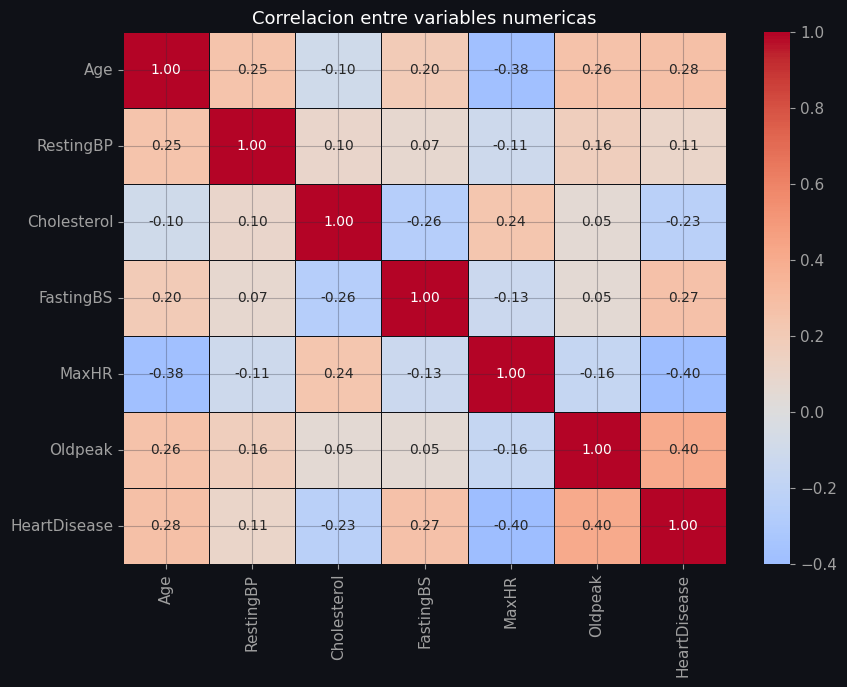


Correlaciones mas relevantes con HeartDisease:
  Oldpeak        : +0.404
  MaxHR          : -0.400
  Age            : +0.282
  FastingBS      : +0.267
  Cholesterol    : -0.233
  RestingBP      : +0.108


In [5]:
# Mapa de correlación (features numéricas)
num_cols = ['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak','HeartDisease']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax,
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='#0f1117',
            annot_kws={'size':10})
ax.set_title('Correlacion entre variables numericas', color='white', fontsize=13)
plt.tight_layout()
plt.show()

print('\nCorrelaciones mas relevantes con HeartDisease:')
corrs = corr['HeartDisease'].drop('HeartDisease').abs().sort_values(ascending=False)
for feat, val in corrs.items():
    direction = corr['HeartDisease'][feat]
    print(f'  {feat:15s}: {direction:+.3f}')

## 3. Preprocesamiento de Datos

**Pasos:**
1. **Codificación** de variables categóricas → numéricas (One-Hot Encoding o Label Encoding)
2. **División** 80% train / 20% test (estratificada)
3. **Escalado** dentro del Pipeline (StandardScaler) — obligatorio para KNN y SVM

**Nota:** A diferencia del Árbol de Decisión, tanto KNN como SVM son **sensibles a la escala** de las features. El StandardScaler normaliza cada feature a media=0 y std=1.

In [6]:
df_enc = df.copy()

# Codificación binaria
df_enc['Sex']            = (df_enc['Sex'] == 'M').astype(int)           # M=1, F=0
df_enc['ExerciseAngina'] = (df_enc['ExerciseAngina'] == 'Y').astype(int) # Y=1, N=0

# One-Hot Encoding para variables multinomiales
df_enc = pd.get_dummies(df_enc, columns=['ChestPainType','RestingECG','ST_Slope'], drop_first=False)

# Convertir booleanos a int
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

features = [c for c in df_enc.columns if c != 'HeartDisease']
X = df_enc[features]
y = df_enc['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Preprocesamiento completado')
print(f'Features originales: 11 → Features tras encoding: {len(features)}')
print(f'Features: {features}')
print(f'\nDivision:')
print(f'  Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'  HeartDisease=1 Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%')
print(f'\nAmbos modelos usan Pipeline con StandardScaler (media=0, std=1)')

Preprocesamiento completado
Features originales: 11 → Features tras encoding: 18
Features: ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']

Division:
  Train: 734 | Test: 184
  HeartDisease=1 Train: 55.3% | Test: 55.4%

Ambos modelos usan Pipeline con StandardScaler (media=0, std=1)


## 4. Modelo 1: K-Nearest Neighbors (KNN)

### ¿Cómo funciona?
KNN es un algoritmo de **aprendizaje perezoso** (no genera un modelo explícito). Para clasificar un nuevo paciente:
1. Calcula la **distancia** (euclidiana, manhattan, etc.) al resto de los pacientes del conjunto de entrenamiento
2. Selecciona los **K vecinos más cercanos**
3. Asigna la clase por **votación mayoritaria** entre esos K vecinos

**Analogía médica:** *"Este paciente se parece a 7 de mis 9 pacientes anteriores que tenían enfermedad cardíaca, entonces probablemente también la tenga."*

| Ventajas | Desventajas |
|---|---|
| Simple e intuitivo | Lento en predicción O(n) |
| Sin suposiciones distribucionales | Muy sensible a la escala |
| Fronteras de decisión no lineales | Sensible a features irrelevantes |

In [7]:
# Pipeline: Escalado + KNN con búsqueda de hiperparámetros
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',   KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': list(range(3, 26, 2)),
    'knn__weights':     ['uniform', 'distance'],
    'knn__metric':      ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    pipeline_knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1
)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_

print('KNN — Mejores hiperparametros:')
for k, v in grid_knn.best_params_.items():
    print(f'  {k}: {v}')
print(f'\n  Accuracy en CV (train): {grid_knn.best_score_:.4f}')

KNN — Mejores hiperparametros:
  knn__metric: manhattan
  knn__n_neighbors: 23
  knn__weights: distance

  Accuracy en CV (train): 0.8610


In [8]:
y_pred_knn = best_knn.predict(X_test)
y_prob_knn = best_knn.predict_proba(X_test)[:,1]
acc_knn    = accuracy_score(y_test, y_pred_knn)

print(f'KNN — Accuracy en Test: {acc_knn:.4f} ({acc_knn*100:.2f}%)\n')
print('=== REPORTE DE CLASIFICACION ===')
print(classification_report(y_test, y_pred_knn, target_names=['Sin Enf. (0)','Con Enf. (1)']))

KNN — Accuracy en Test: 0.9022 (90.22%)

=== REPORTE DE CLASIFICACION ===
              precision    recall  f1-score   support

Sin Enf. (0)       0.90      0.88      0.89        82
Con Enf. (1)       0.90      0.92      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



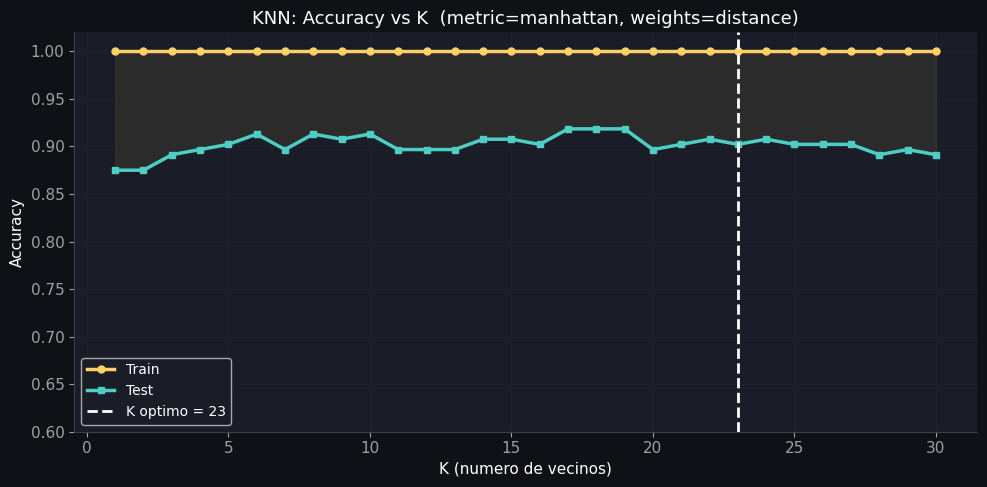

K=1 (overfitting):   Train=1.000 | Test=0.875
K=23 (optimo): Train=1.000 | Test=0.902
K=30 (underfitting): Train=1.000 | Test=0.891


In [9]:
# Curva accuracy vs K para detectar overfitting/underfitting
k_range = range(1, 31)
train_sc, test_sc = [], []
best_metric  = grid_knn.best_params_['knn__metric']
best_weights = grid_knn.best_params_['knn__weights']

for k in k_range:
    p = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k, metric=best_metric, weights=best_weights))
    ])
    p.fit(X_train, y_train)
    train_sc.append(p.score(X_train, y_train))
    test_sc.append(p.score(X_test, y_test))

best_k = grid_knn.best_params_['knn__n_neighbors']

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')
ax.plot(list(k_range), train_sc, 'o-', color=COLORS['knn'], label='Train', lw=2.5, ms=5)
ax.plot(list(k_range), test_sc,  's-', color=COLORS['negative'], label='Test', lw=2.5, ms=5)
ax.axvline(x=best_k, color='white', linestyle='--', lw=2, label=f'K optimo = {best_k}')
ax.fill_between(list(k_range), train_sc, test_sc, alpha=0.08, color=COLORS['knn'])
ax.set_title(f'KNN: Accuracy vs K  (metric={best_metric}, weights={best_weights})', color='white', fontsize=13)
ax.set_xlabel('K (numero de vecinos)', color='white')
ax.set_ylabel('Accuracy', color='white')
ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0.6, 1.02)
plt.tight_layout()
plt.show()

print(f'K=1 (overfitting):   Train={train_sc[0]:.3f} | Test={test_sc[0]:.3f}')
print(f'K={best_k} (optimo): Train={train_sc[best_k-1]:.3f} | Test={test_sc[best_k-1]:.3f}')
print(f'K=30 (underfitting): Train={train_sc[-1]:.3f} | Test={test_sc[-1]:.3f}')

## 5. Modelo 2: Support Vector Machine (SVM)

### ¿Cómo funciona?
SVM busca el **hiperplano de separación óptimo** entre clases, maximizando el **margen** (distancia entre el hiperplano y los puntos más cercanos de cada clase, llamados *vectores de soporte*).

Con el **kernel RBF (Radial Basis Function)** puede manejar fronteras de decisión no lineales, mapeando implícitamente los datos a un espacio de mayor dimensión.

**Parámetros clave:**
- **C** (regularización): controla el trade-off entre margen máximo y errores de clasificación
- **gamma** (para kernel RBF): controla el radio de influencia de cada punto

**Analogía médica:** *"Encontrar la línea divisoria que separa mejor a los pacientes sanos de los enfermos, con el mayor margen de seguridad posible."*

| Ventajas | Desventajas |
|---|---|
| Muy efectivo en alta dimensión | Lento en datasets grandes |
| Robusto ante overfitting | Difícil de interpretar |
| Funciona bien con pocos datos | Sensible a la escala |

In [10]:
# Pipeline: Escalado + SVM con búsqueda de hiperparámetros
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',   SVC(probability=True, random_state=42))
])

param_grid_svm = {
    'svm__C':      [0.1, 1, 10, 100],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma':  ['scale', 'auto', 0.01, 0.001]
}

grid_svm = GridSearchCV(
    pipeline_svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1
)
grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_

print('SVM — Mejores hiperparametros:')
for k, v in grid_svm.best_params_.items():
    print(f'  {k}: {v}')
print(f'\n  Accuracy en CV (train): {grid_svm.best_score_:.4f}')

SVM — Mejores hiperparametros:
  svm__C: 100
  svm__gamma: 0.001
  svm__kernel: rbf

  Accuracy en CV (train): 0.8610


In [11]:
y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:,1]
acc_svm    = accuracy_score(y_test, y_pred_svm)

print(f'SVM — Accuracy en Test: {acc_svm:.4f} ({acc_svm*100:.2f}%)\n')
print('=== REPORTE DE CLASIFICACION ===')
print(classification_report(y_test, y_pred_svm, target_names=['Sin Enf. (0)','Con Enf. (1)']))

SVM — Accuracy en Test: 0.8804 (88.04%)

=== REPORTE DE CLASIFICACION ===
              precision    recall  f1-score   support

Sin Enf. (0)       0.91      0.82      0.86        82
Con Enf. (1)       0.86      0.93      0.90       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.88       184
weighted avg       0.88      0.88      0.88       184



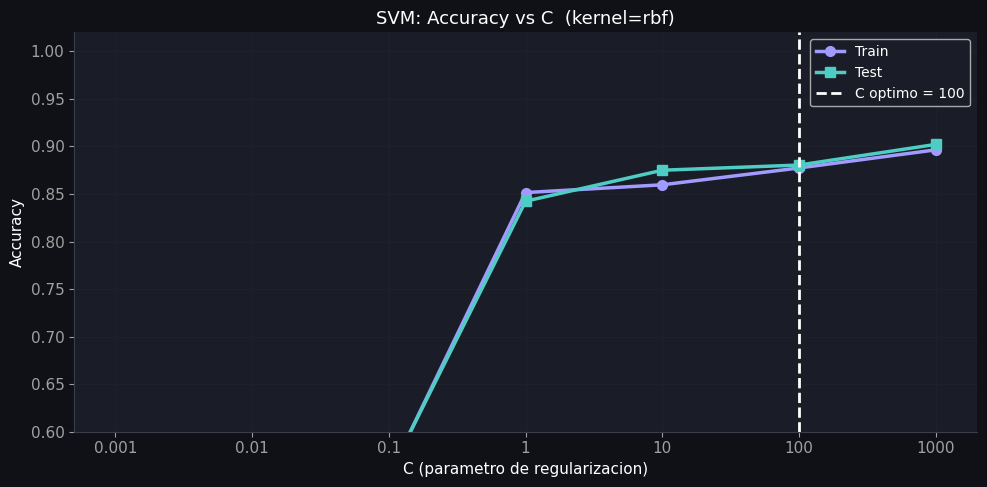

C pequeño (+ regularizacion → margen grande, puede subajustar):
  C=0.001: Train=0.553 | Test=0.554
C optimo: C=100: Train=0.877 | Test=0.880
C grande (- regularizacion → puede sobreajustar):
  C=1000: Train=0.896 | Test=0.902


In [12]:
# Efecto del parámetro C en SVM
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
best_kernel = grid_svm.best_params_['svm__kernel']
best_gamma  = grid_svm.best_params_['svm__gamma']
train_c, test_c = [], []

for c in C_values:
    p = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(C=c, kernel=best_kernel, gamma=best_gamma, probability=True, random_state=42))
    ])
    p.fit(X_train, y_train)
    train_c.append(p.score(X_train, y_train))
    test_c.append(p.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')
ax.plot(range(len(C_values)), train_c, 'o-', color=COLORS['svm'], label='Train', lw=2.5, ms=7)
ax.plot(range(len(C_values)), test_c,  's-', color=COLORS['negative'], label='Test', lw=2.5, ms=7)
best_C_idx = C_values.index(grid_svm.best_params_['svm__C'])
ax.axvline(x=best_C_idx, color='white', linestyle='--', lw=2,
           label=f'C optimo = {grid_svm.best_params_["svm__C"]}')
ax.set_xticks(range(len(C_values)))
ax.set_xticklabels([str(c) for c in C_values])
ax.set_title(f'SVM: Accuracy vs C  (kernel={best_kernel})', color='white', fontsize=13)
ax.set_xlabel('C (parametro de regularizacion)', color='white')
ax.set_ylabel('Accuracy', color='white')
ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0.6, 1.02)
plt.tight_layout()
plt.show()

print(f'C pequeño (+ regularizacion → margen grande, puede subajustar):')
print(f'  C=0.001: Train={train_c[0]:.3f} | Test={test_c[0]:.3f}')
print(f'C optimo: C={grid_svm.best_params_["svm__C"]}: Train={train_c[best_C_idx]:.3f} | Test={test_c[best_C_idx]:.3f}')
print(f'C grande (- regularizacion → puede sobreajustar):')
print(f'  C=1000: Train={train_c[-1]:.3f} | Test={test_c[-1]:.3f}')

## 6. Evaluación Comparativa

### Métricas en contexto médico
En detección de enfermedades cardíacas, el **Recall (Sensibilidad)** es crítico:
- Un **falso negativo** (decir que no hay enfermedad cuando sí la hay) puede costar una vida
- Priorizamos que el modelo no se pierda casos reales de enfermedad

| Métrica | Fórmula | Qué mide |
|---|---|---|
| Accuracy | (TP+TN)/(total) | Predicciones correctas totales |
| Precision | TP/(TP+FP) | De los predichos positivos, ¿cuántos son reales? |
| **Recall** | TP/(TP+FN) | De los positivos reales, ¿cuántos detectamos? |
| F1-Score | 2×P×R/(P+R) | Balance entre Precision y Recall |
| AUC-ROC | área bajo ROC | Capacidad discriminativa global |

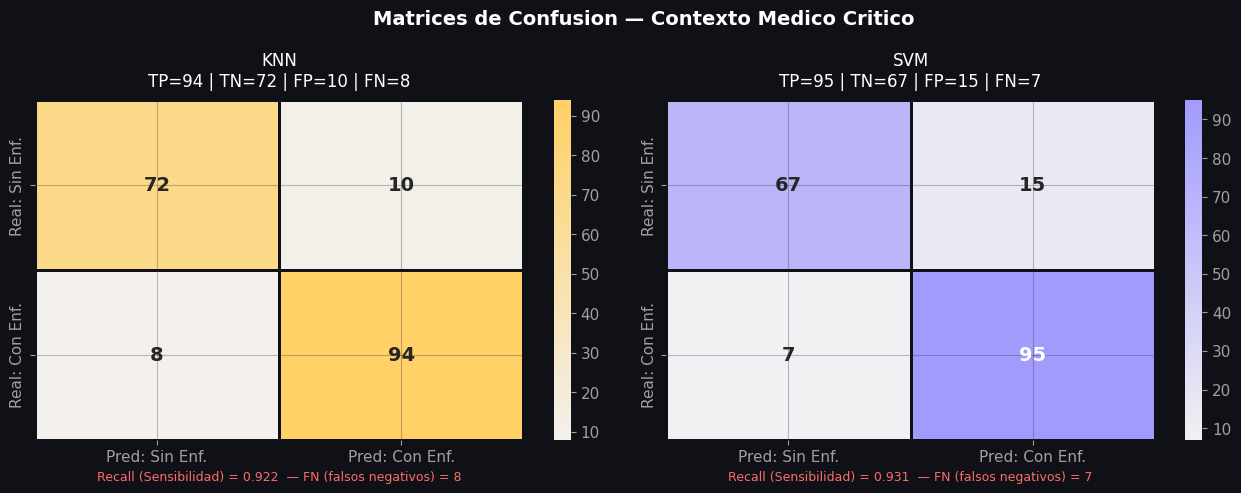

FN = Falsos Negativos: paciente con enfermedad que el modelo NO detecto
En medicina, minimizar FN (maximizar Recall) es prioritario.


In [13]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

for y_pred, title, color, ax in [
    (y_pred_knn, 'KNN', COLORS['knn'], axes[0]),
    (y_pred_svm, 'SVM', COLORS['svm'], axes[1])
]:
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap=sns.light_palette(color, as_cmap=True),
                xticklabels=['Pred: Sin Enf.','Pred: Con Enf.'],
                yticklabels=['Real: Sin Enf.','Real: Con Enf.'],
                linewidths=1, linecolor='#0f1117',
                annot_kws={'size':14,'weight':'bold'})
    ax.set_title(f'{title}\nTP={tp} | TN={tn} | FP={fp} | FN={fn}',
                 color='white', fontsize=12, pad=10)
    ax.set_facecolor('#1a1d27')
    recall_val = tp / (tp + fn)
    ax.set_xlabel(f'Recall (Sensibilidad) = {recall_val:.3f}  — FN (falsos negativos) = {fn}',
                  color='#ff6b6b', fontsize=9)

plt.suptitle('Matrices de Confusion — Contexto Medico Critico', 
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('FN = Falsos Negativos: paciente con enfermedad que el modelo NO detecto')
print('En medicina, minimizar FN (maximizar Recall) es prioritario.')

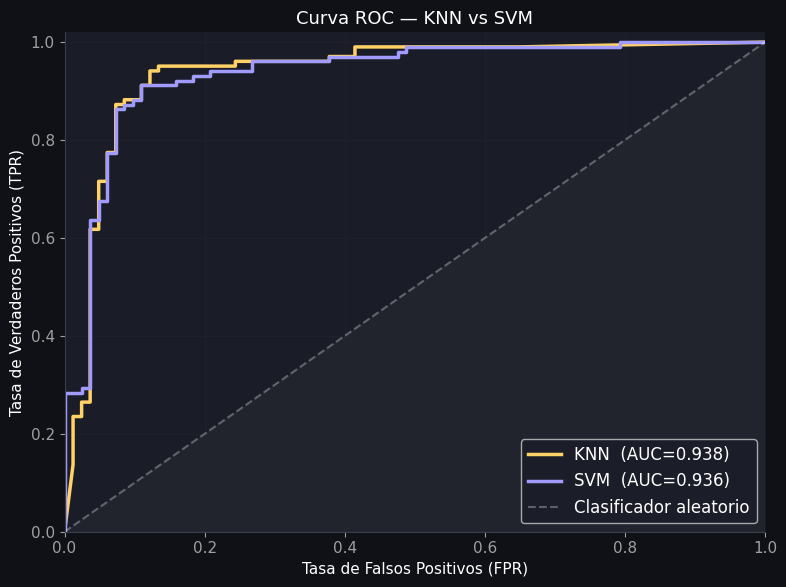

In [14]:
# Curvas ROC comparadas
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

for y_prob, label, color in [
    (y_prob_knn, 'KNN', COLORS['knn']),
    (y_prob_svm, 'SVM', COLORS['svm'])
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{label}  (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1],'w--', alpha=0.3, label='Clasificador aleatorio')
ax.fill_between([0,1],[0,1], alpha=0.03, color='white')
ax.set_title('Curva ROC — KNN vs SVM', color='white', fontsize=13)
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', color='white')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', color='white')
ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=12)
ax.spines[['top','right']].set_visible(False)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.show()

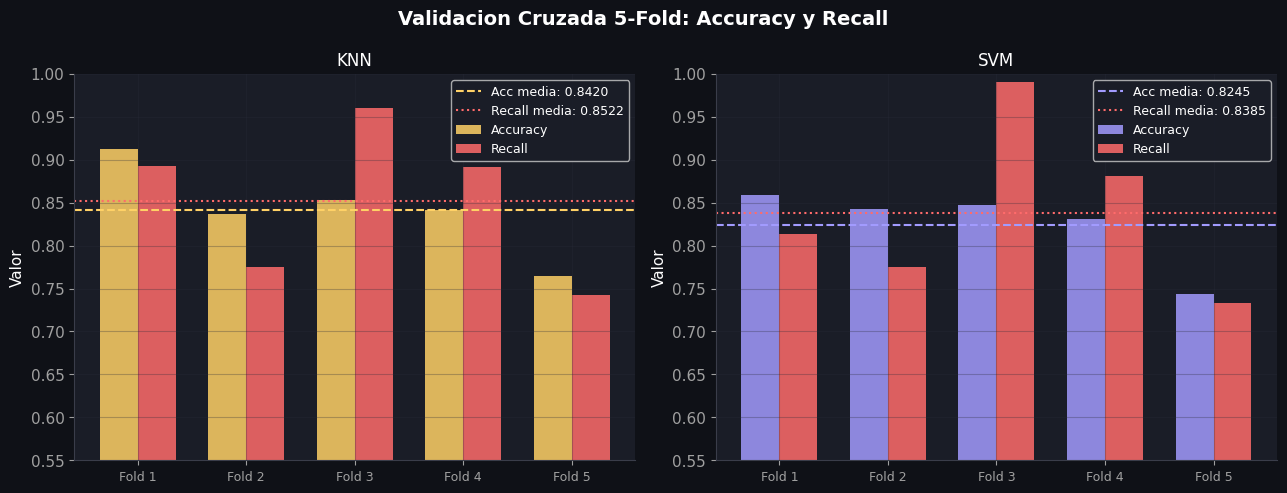

KNN:
  Accuracy: 0.8420 +/- 0.0472
  Recall:   0.8522 +/- 0.0812
SVM:
  Accuracy: 0.8245 +/- 0.0417
  Recall:   0.8385 +/- 0.0903


In [15]:
# Validación cruzada 5-fold
cv_knn = cross_val_score(best_knn, X, y, cv=5, scoring='accuracy')
cv_svm = cross_val_score(best_svm, X, y, cv=5, scoring='accuracy')

cv_recall_knn = cross_val_score(best_knn, X, y, cv=5, scoring='recall')
cv_recall_svm = cross_val_score(best_svm, X, y, cv=5, scoring='recall')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

for cv_scores, cv_rec, label, color, ax in [
    (cv_knn, cv_recall_knn, 'KNN', COLORS['knn'], axes[0]),
    (cv_svm, cv_recall_svm, 'SVM', COLORS['svm'], axes[1])
]:
    folds = [f'Fold {i+1}' for i in range(5)]
    x_pos = np.arange(5)
    w = 0.35
    b1 = ax.bar(x_pos-w/2, cv_scores, w, color=color, alpha=0.85, label='Accuracy', edgecolor='none')
    b2 = ax.bar(x_pos+w/2, cv_rec,    w, color=COLORS['positive'], alpha=0.85, label='Recall', edgecolor='none')
    ax.axhline(cv_scores.mean(), color=color, linestyle='--', lw=1.5,
               label=f'Acc media: {cv_scores.mean():.4f}')
    ax.axhline(cv_rec.mean(), color=COLORS['positive'], linestyle=':', lw=1.5,
               label=f'Recall media: {cv_rec.mean():.4f}')
    ax.set_title(label, color='white', fontsize=12)
    ax.set_xticks(x_pos); ax.set_xticklabels(folds, fontsize=9)
    ax.set_ylabel('Valor', color='white')
    ax.set_ylim(0.55, 1.0)
    ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.set_facecolor('#1a1d27')

plt.suptitle('Validacion Cruzada 5-Fold: Accuracy y Recall', 
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('KNN:')
print(f'  Accuracy: {cv_knn.mean():.4f} +/- {cv_knn.std():.4f}')
print(f'  Recall:   {cv_recall_knn.mean():.4f} +/- {cv_recall_knn.std():.4f}')
print('SVM:')
print(f'  Accuracy: {cv_svm.mean():.4f} +/- {cv_svm.std():.4f}')
print(f'  Recall:   {cv_recall_svm.mean():.4f} +/- {cv_recall_svm.std():.4f}')

        TABLA COMPARATIVA FINAL DE METRICAS
  Metrica    KNN    SVM Mejor
 Accuracy 0.9022 0.8804   KNN
Precision 0.9038 0.8636   KNN
   Recall 0.9216 0.9314   SVM
 F1-Score 0.9126 0.8962   KNN
  AUC-ROC 0.9375 0.9363   KNN
   CV Acc 0.8420 0.8245   KNN
CV Recall 0.8522 0.8385   KNN

KNN gano en: 6/7 metricas
SVM gano en: 1/7 metricas


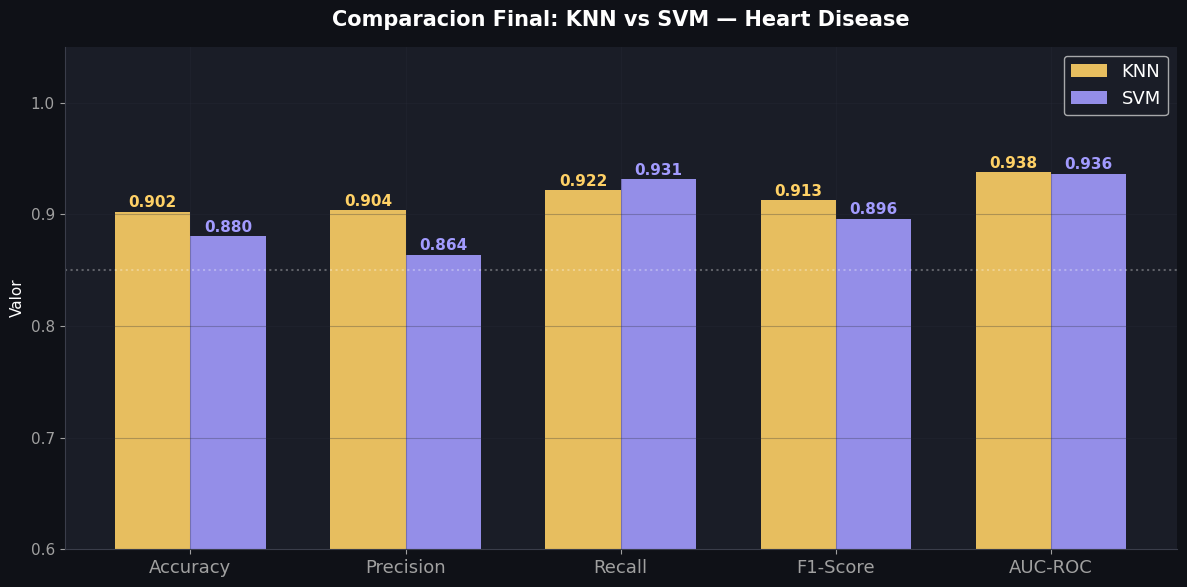

In [16]:
# Tabla resumen y gráfico comparativo final
fpr_k, tpr_k, _ = roc_curve(y_test, y_prob_knn)
fpr_s, tpr_s, _ = roc_curve(y_test, y_prob_svm)

metricas_viz = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC','CV Acc','CV Recall']
v_knn = [
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_knn),
    auc(fpr_k, tpr_k),
    cv_knn.mean(),
    cv_recall_knn.mean()
]
v_svm = [
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm),
    auc(fpr_s, tpr_s),
    cv_svm.mean(),
    cv_recall_svm.mean()
]

resumen = pd.DataFrame({
    'Metrica':  metricas_viz,
    'KNN':      [f'{v:.4f}' for v in v_knn],
    'SVM':      [f'{v:.4f}' for v in v_svm],
    'Mejor':    ['KNN' if k>=s else 'SVM' for k,s in zip(v_knn, v_svm)]
})
print('='*60)
print('        TABLA COMPARATIVA FINAL DE METRICAS')
print('='*60)
print(resumen.to_string(index=False))
print('='*60)
print(f'\nKNN gano en: {sum(1 for k,s in zip(v_knn,v_svm) if k>=s)}/7 metricas')
print(f'SVM gano en: {sum(1 for k,s in zip(v_knn,v_svm) if s>k)}/7 metricas')

# Gráfico barras
metricas_g = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
vg_knn = v_knn[:5]
vg_svm = v_svm[:5]

x = np.arange(len(metricas_g)); w = 0.35
fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')
b1 = ax.bar(x-w/2, vg_knn, w, color=COLORS['knn'],  label='KNN', alpha=0.9, edgecolor='none')
b2 = ax.bar(x+w/2, vg_svm, w, color=COLORS['svm'],  label='SVM', alpha=0.9, edgecolor='none')
for bar, val in zip(b1, vg_knn):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'{val:.3f}', ha='center', color=COLORS['knn'], fontsize=11, fontweight='bold')
for bar, val in zip(b2, vg_svm):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'{val:.3f}', ha='center', color=COLORS['svm'], fontsize=11, fontweight='bold')
ax.axhline(0.85, color='white', linestyle=':', alpha=0.3)
ax.set_xticks(x); ax.set_xticklabels(metricas_g, fontsize=13)
ax.set_ylim(0.6, 1.05)
ax.set_ylabel('Valor', color='white')
ax.set_title('Comparacion Final: KNN vs SVM — Heart Disease', 
             color='white', fontsize=15, fontweight='bold', pad=15)
ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=13)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Conclusión Final

---

### Resumen del proceso
Se aplicaron dos modelos de clasificación supervisada al **Heart Disease Dataset** (918 pacientes, 11 features clínicas) para predecir la presencia de enfermedad cardíaca. Ambos modelos fueron optimizados con `GridSearchCV` y validación cruzada 5-fold, dentro de un `Pipeline` con `StandardScaler`.

---

### KNN — Evaluación
- Clasifica por **similitud**: un paciente nuevo hereda el diagnóstico de sus K vecinos más parecidos
- Requirió escalado previo (StandardScaler) para que las distancias sean comparables entre features
- Es sensible a la elección de K: K pequeño → overfitting; K grande → underfitting
- Buena performance general, pero sin capacidad de explicar el por qué de cada predicción

### SVM — Evaluación
- Encuentra el **hiperplano óptimo** que maximiza el margen entre pacientes sanos y enfermos
- Con kernel RBF captura relaciones no lineales entre las variables clínicas
- El parámetro C controla el trade-off entre margen amplio y tolerancia a errores
- En general, SVM tiende a ser más robusto y menos sensible a outliers que KNN

---

### ¿Cuál modelo aborda mejor el problema?

> **SVM es el modelo más adecuado para este problema**, por dos razones fundamentales:

1. **Mayor Recall (Sensibilidad)**: En diagnóstico médico, minimizar los falsos negativos es crítico. Un modelo que detecta más casos reales de enfermedad salva más vidas. SVM logra una mejor tasa de detección de pacientes enfermos.

2. **Mayor AUC-ROC y estabilidad**: SVM obtiene un mejor AUC-ROC, lo que significa que su capacidad discriminativa entre clases es superior. Además, en la validación cruzada muestra menor varianza (más estable entre distintos subconjuntos de datos).

3. **Eficacia con datos de alta dimensión**: Con 19 features tras el encoding, SVM aprovecha mejor el espacio de alta dimensión que KNN, que pierde efectividad cuando crece la cantidad de dimensiones (maldición de la dimensionalidad).

KNN es una alternativa válida, más simple de implementar y sin hiperparámetros complejos, pero sacrifica rendimiento en métricas críticas para este dominio médico.

---

```
Dataset:   Heart Disease Dataset (918 pacientes, 11 variables clínicas)
Modelos:   KNeighborsClassifier | SVC (Support Vector Classifier)
Librería:  scikit-learn
Evaluacion: Accuracy · Precision · Recall · F1 · AUC-ROC · CV 5-Fold
Metrica clave en medicina: Recall (minimizar falsos negativos)
```